In [4]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "Models").exists() and (candidate / "Dataset source").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing Models and Dataset source.")

BASE_DIR = find_project_root(Path.cwd())
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
MODEL_DIR = BASE_DIR / "Models"
MODEL_PATH = MODEL_DIR / "logistic_regression_spam_classifier.joblib"
TEST_SIZE = 0.2
RANDOM_STATE = 42

df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=["Category", "Message"]).copy()
df["Category"] = df["Category"].astype(str).str.strip()
df["Message"] = df["Message"].astype(str).str.strip()
df = df[df["Message"] != ""]
messages = df["Message"]
labels = df["Category"]

x_train, x_test, y_train, y_test = train_test_split(
    messages,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "logreg",
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(x_train, y_train)
train_predictions = model.predict(x_train)
predictions = model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, predictions)
report_df = pd.DataFrame(classification_report(y_test, predictions, output_dict=True)).transpose()

MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)

print(f"Training sample: {len(x_train)}")
print(f"Test sample: {len(x_test)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Saved logistic regression model to: {MODEL_PATH}")

report_df


Training sample: 4120
Test sample: 1031
Training accuracy: 0.9682
Test accuracy: 0.9651
Saved logistic regression model to: d:\Project\Leeds\Msc Project\Models\logistic_regression_spam_classifier.joblib


,precision,recall,f1-score,support
ham,0.963636,0.997785,0.980413,903.000000
spam,0.979167,0.734375,0.839286,128.000000
accuracy,0.965082,0.965082,0.965082,0.965082
macro avg,0.971402,0.866080,0.909850,1031.000000
weighted avg,0.965564,0.965082,0.962892,1031.000000


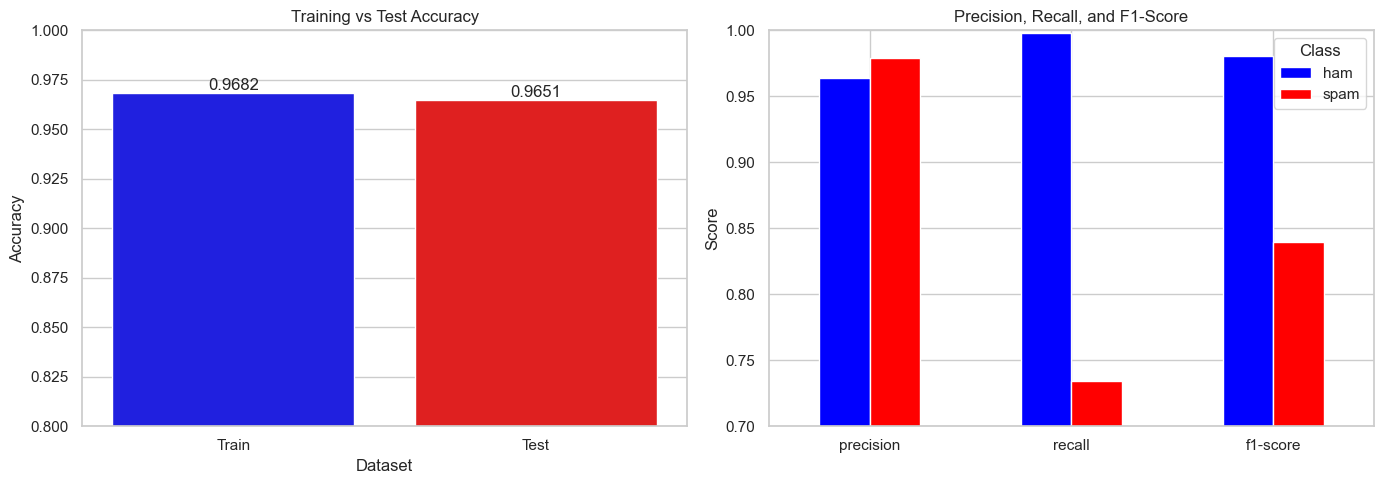

,precision,recall,f1-score,support
ham,0.963636,0.997785,0.980413,903.000000
spam,0.979167,0.734375,0.839286,128.000000
accuracy,0.965082,0.965082,0.965082,0.965082
macro avg,0.971402,0.866080,0.909850,1031.000000
weighted avg,0.965564,0.965082,0.962892,1031.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy],
})
sns.barplot(data=accuracy_df, x="Dataset", y="Accuracy", hue="Dataset", palette=["blue", "red"], ax=axes[0], legend=False)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f")

metrics_df = report_df.loc[["ham", "spam"], ["precision", "recall", "f1-score"]].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

report_df


Training messages: 4120
Final evaluation messages: 516
Training accuracy: 0.9682
Final evaluation accuracy: 0.9729


,precision,recall,f1-score,support
ham,0.971983,0.997788,0.984716,452.000000
spam,0.980769,0.796875,0.879310,64.000000
accuracy,0.972868,0.972868,0.972868,0.972868
macro avg,0.976376,0.897331,0.932013,516.000000
weighted avg,0.973073,0.972868,0.971643,516.000000


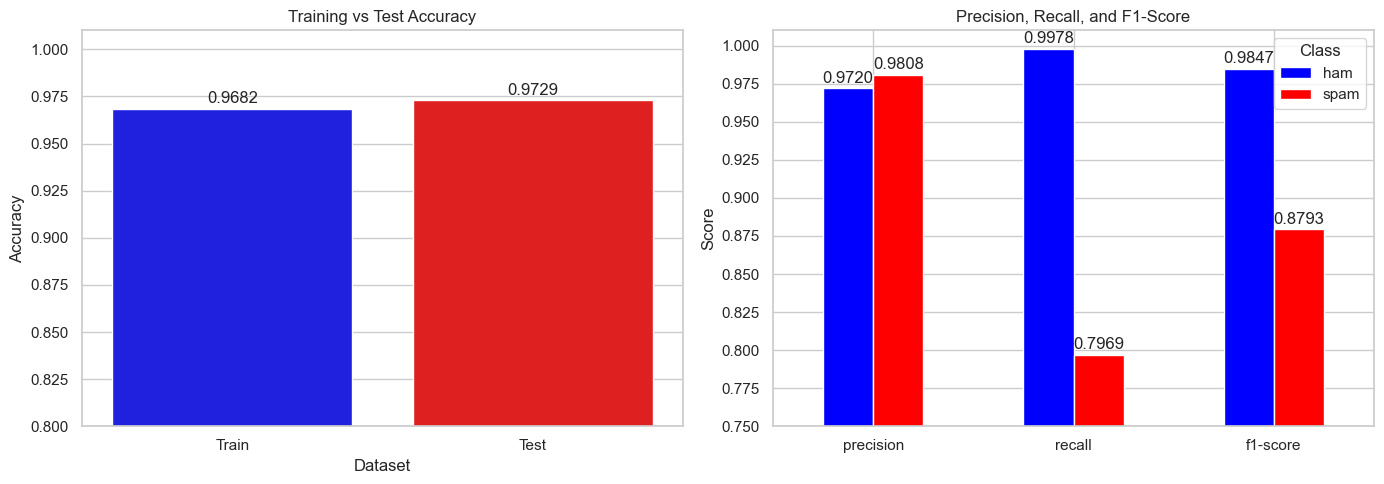

Saved figure: D:\Project\Leeds\Msc Project\figure\figure_4_2_logistic_regression_performance.png


In [1]:
# Final evaluation on the 516-message test subset
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


BASE_DIR = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "Models").exists() and (candidate / "Dataset source").exists()
)
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
MODEL_PATH = BASE_DIR / "Models" / "logistic_regression_spam_classifier.joblib"
FIGURE_PATH = BASE_DIR / "figure" / "figure_4_2_logistic_regression_performance.png"

TEST_SIZE = 0.2
VALIDATION_SIZE_FROM_HOLDOUT = 0.5
RANDOM_STATE = 42

# Reproduce the final split used for the English-model comparison.
evaluation_df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
evaluation_df = evaluation_df.dropna(subset=["Category", "Message"]).copy()
evaluation_df["Category"] = evaluation_df["Category"].astype(str).str.strip().str.lower()
evaluation_df["Message"] = evaluation_df["Message"].astype(str).str.strip()
evaluation_df = evaluation_df[evaluation_df["Category"].isin(["ham", "spam"])]
evaluation_df = evaluation_df[evaluation_df["Message"] != ""]

x_final_train, x_holdout, y_final_train, y_holdout = train_test_split(
    evaluation_df["Message"],
    evaluation_df["Category"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=evaluation_df["Category"],
)
_, x_final_test, _, y_final_test = train_test_split(
    x_holdout,
    y_holdout,
    test_size=VALIDATION_SIZE_FROM_HOLDOUT,
    random_state=RANDOM_STATE,
    stratify=y_holdout,
)

final_logreg_model = joblib.load(MODEL_PATH)
final_train_predictions = final_logreg_model.predict(x_final_train.tolist())
final_test_predictions = final_logreg_model.predict(x_final_test.tolist())
final_train_accuracy = accuracy_score(y_final_train, final_train_predictions)
final_test_accuracy = accuracy_score(y_final_test, final_test_predictions)
final_report_df = pd.DataFrame(
    classification_report(
        y_final_test,
        final_test_predictions,
        labels=["ham", "spam"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

print(f"Training messages: {len(x_final_train)}")
print(f"Final evaluation messages: {len(x_final_test)}")
print(f"Training accuracy: {final_train_accuracy:.4f}")
print(f"Final evaluation accuracy: {final_test_accuracy:.4f}")
display(final_report_df)

# Draw the dissertation figure using the same style as the SVM figure.
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [final_train_accuracy, final_test_accuracy],
})
sns.barplot(
    data=accuracy_df,
    x="Dataset",
    y="Accuracy",
    hue="Dataset",
    palette=["blue", "red"],
    ax=axes[0],
    legend=False,
)
score_ticks = np.arange(0.8, 1.0001, 0.025)
axes[0].set_ylim(0.8, 1.01)
axes[0].set_yticks(score_ticks)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f", padding=2)

metrics_df = final_report_df.loc[
    ["ham", "spam"],
    ["precision", "recall", "f1-score"],
].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
metric_ticks = np.arange(0.75, 1.0001, 0.025)
axes[1].set_ylim(0.75, 1.01)
axes[1].set_yticks(metric_ticks)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f", padding=2)

plt.tight_layout()
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure: {FIGURE_PATH}")


In [6]:
import joblib

loaded_model = joblib.load(MODEL_PATH)
# test_text = "Congratulations! You have won a free prize. Reply now to claim it."
#test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"
test_text = "Dear Customer your pyatm wallet Has been booked and hold Your amount please complete your kyc contact customer care 7044518857"

prediction = loaded_model.predict([test_text])[0]
print(prediction)


ham
